# Lesson D - Advanced LangGraph Patterns
**Presented by:** Sharad Rajore | **Organization:** Zensar Technologies

---

### Learning Objectives
1. **Human-in-the-Loop:** Pause a graph with `interrupt()` and resume it with `Command(resume=...)` before a sensitive tool runs.
2. **Custom State:** Go beyond `messages` with your own state fields and reducers.
3. **Fan-Out / Fan-In:** Run independent nodes in parallel and merge their results safely.
4. **Multi-Agent Graphs:** Compose a supervisor that routes between specialist sub-graphs.
5. **Durable Memory:** Swap `MemorySaver` for a persistent `SqliteSaver` checkpointer.

### Why this lesson exists
Lesson C gave us the shape of a LangGraph agent: `State`, `Node`, `Edge`, one `Conditional edge`, and `MemorySaver`.

That shape is enough for a demo. It is not yet enough for the patterns real LangGraph projects reach for:

| Real need | Lesson C | Lesson D |
|---|---|---|
| Approve a risky action before it runs | not covered | `interrupt()` + `Command` |
| Track more than the message list | not covered | custom state + reducers |
| Do independent work at the same time | not covered | fan-out / fan-in |
| Multiple specialized agents | not covered | sub-graphs as nodes |
| Memory that survives a restart | `MemorySaver` (in-process only) | `SqliteSaver` |

---

**Where this fits in the course:**
- Lesson A: Short-term memory with `checkpointer` + `thread_id`
- Lesson B: Long-term memory with `store` + `user_id`
- Lesson C: Explicit LangGraph workflows
- **Lesson D: Advanced LangGraph patterns**
- Next: MCP tools plugged into LangGraph

## Setup

In [1]:
from dotenv import load_dotenv
load_dotenv()

import importlib.metadata as metadata
import langchain

print(f"LangChain: {langchain.__version__}")
print(f"LangGraph: {metadata.version('langgraph')}")
print(f"langgraph-checkpoint-sqlite: {metadata.version('langgraph-checkpoint-sqlite')}")

LangChain: 1.3.9
LangGraph: 1.2.5
langgraph-checkpoint-sqlite: 3.1.0


In [2]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="gpt-oss:120b-cloud", temperature=0)

# -- Alternatively, use Groq --------------------------------------------------
# from langchain_groq import ChatGroq
# llm = ChatGroq(model="llama-3.3-70b-versatile")
# ------------------------------------------------------------------------------

print("LLM ready.")

LLM ready.


In [3]:
from langchain_core.tools import tool

# Reusing familiar local tools from Lesson C
@tool
def get_weather(city: str) -> str:
    """Returns the current weather for a given city."""
    return f"The weather in {city} is sunny with a high of 28C."

@tool
def get_stock_price(ticker: str) -> str:
    """Returns the current stock price for a given ticker symbol.
    Use 'ZENSAR' for Zensar Technologies, 'GOOGL' for Google."""
    prices = {"ZENSAR": "464.00 INR", "GOOGL": "175.00 USD"}
    return prices.get(ticker.upper(), f"Unknown ticker: {ticker}")

# A new, deliberately "sensitive" tool for the human-in-the-loop demo
@tool
def transfer_funds(amount: float, to_account: str) -> str:
    """Transfers money to a bank account. This is a sensitive action that
    should always be approved by a human before it runs."""
    return f"Transferred {amount} to {to_account}."

TOOLS = [get_weather, get_stock_price]
ALL_TOOLS = TOOLS + [transfer_funds]
print("Tools ready: get_weather, get_stock_price, transfer_funds")

Tools ready: get_weather, get_stock_price, transfer_funds


In [4]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

class AgentState(TypedDict):
    # add_messages appends new messages instead of replacing the whole list
    messages: Annotated[list[AnyMessage], add_messages]

def route_after_assistant(state: AgentState) -> str:
    """Route to tools only when the model produced tool calls."""
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END

print("AgentState and base router ready (same shape as Lesson C).")

AgentState and base router ready (same shape as Lesson C).


---
## Part 1: Human-in-the-Loop with `interrupt()`

Some tool calls should never run automatically: transferring money, deleting a record, sending an email to a customer.

LangGraph lets us **pause** the graph mid-run with `interrupt()`, hand control back to a human, and **resume** with `Command(resume=...)` once a decision is made.

The routing idea:

```
assistant -> sensitive tool requested? -> human_review -> approved? -> tools
                                                        -> denied?   -> assistant (with a denial message)
          -> safe tool requested?      -> tools
          -> no tool needed            -> END
```

A checkpointer is **required** for `interrupt()` - the graph needs somewhere to save its paused state.

In [5]:
from langchain_core.messages import SystemMessage, ToolMessage
from langgraph.types import interrupt, Command

SENSITIVE_TOOLS = {"transfer_funds"}

llm_with_all_tools = llm.bind_tools(ALL_TOOLS)

# Some models will ask for confirmation in plain text instead of calling a
# sensitive tool. We don't want that - human_review is what handles approval,
# so the model's only job is to call the tool.
HITL_SYSTEM_PROMPT = SystemMessage(content=(
    "You have access to get_weather, get_stock_price, and transfer_funds. "
    "When the user asks to transfer funds, immediately call the transfer_funds "
    "tool with the requested amount and account - do not ask the user to confirm "
    "in plain text first. A human reviewer approves or denies the transfer "
    "automatically before it executes, so your job is only to call the tool."
))

def assistant_hitl(state: AgentState) -> dict:
    """Assistant node: same idea as Lesson C, now aware of a sensitive tool."""
    response = llm_with_all_tools.invoke([HITL_SYSTEM_PROMPT] + state["messages"])
    return {"messages": [response]}

def route_after_assistant_hitl(state: AgentState) -> str:
    """Send sensitive tool calls to human_review; everything else follows Lesson C's routing."""
    last_message = state["messages"][-1]
    tool_calls = getattr(last_message, "tool_calls", None)
    if not tool_calls:
        return END
    if any(call["name"] in SENSITIVE_TOOLS for call in tool_calls):
        return "human_review"
    return "tools"

def human_review(state: AgentState) -> Command:
    """Pause the graph and ask a human to approve the pending sensitive tool call."""
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]

    decision = interrupt(
        {
            "question": "Approve this action?",
            "tool": tool_call["name"],
            "args": tool_call["args"],
        }
    )

    if decision == "approve":
        return Command(goto="tools")

    denial = ToolMessage(
        content="Action denied by human reviewer.",
        tool_call_id=tool_call["id"],
    )
    return Command(goto="assistant", update={"messages": [denial]})

print("assistant_hitl, router, and human_review node ready.")

assistant_hitl, router, and human_review node ready.


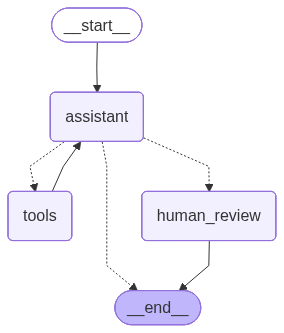

In [13]:
hitl_builder = StateGraph(AgentState)

hitl_builder.add_node("assistant", assistant_hitl)
hitl_builder.add_node("tools", ToolNode(ALL_TOOLS))
hitl_builder.add_node("human_review", human_review)

hitl_builder.add_edge(START, "assistant")
hitl_builder.add_conditional_edges(
    "assistant",
    route_after_assistant_hitl,
    {"tools": "tools", "human_review": "human_review", END: END},
)
hitl_builder.add_edge("tools", "assistant")
# human_review has no static outgoing edge - it returns a Command that
# decides the next node (either "tools" or back to "assistant") at runtime.

hitl_graph = hitl_builder.compile(checkpointer=MemorySaver())
#print(hitl_graph.get_graph().draw_mermaid())
hitl_graph


**Reading the diagram:** it draws `human_review -> __end__` as a guess, because `human_review` has no *static* outgoing edge - it decides its next node at runtime via `Command(goto=...)`. The diagram can't show a decision that only exists at runtime; trust the code over the picture here.

In [14]:
import uuid

# A fresh thread_id each run - so re-running this cell while debugging never
# silently resumes an already-completed thread from a previous attempt.
hitl_config = {"configurable": {"thread_id": f"hitl_demo-{uuid.uuid4().hex[:8]}"}}

pending = hitl_graph.invoke(
    {"messages": [("user", "Please transfer 500 USD to account ACC-9911.")]},
    config=hitl_config,
)

if "__interrupt__" in pending:
    print("Graph paused. Interrupt payload:")
    print(pending["__interrupt__"])
else:
    # No interrupt means human_review was never reached - the model didn't
    # produce a transfer_funds tool call, so the graph ran straight to END.
    last_message = pending["messages"][-1]
    print("No interrupt was raised - the graph ran to completion instead of pausing.")
    print(f"Last message ({last_message.__class__.__name__}): {last_message.content}")
    print(f"Tool calls on last message: {getattr(last_message, 'tool_calls', None)}")

Graph paused. Interrupt payload:
[Interrupt(value={'question': 'Approve this action?', 'tool': 'transfer_funds', 'args': {'amount': 500, 'to_account': 'ACC-9911'}}, id='0d80f677ff8637478e4d139f2a3d54bf')]


### What just happened?

The model requested `transfer_funds`, the router sent it to `human_review`, and `interrupt()` froze the graph right there.

`hitl_graph.invoke(...)` returned instead of blocking forever - the return value's `__interrupt__` key carries the question a human needs to answer.

Now we resume the **same thread** with a decision.

In [15]:
# Try flipping this to "deny" and re-running both cells above + this one
# to see the assistant receive a denial message instead.
approved = hitl_graph.invoke(Command(resume="approve"), config=hitl_config)

print("Final answer:")
print(approved["messages"][-1].content)
print()
print("Messages captured in graph state:")
for i, msg in enumerate(approved["messages"], 1):
    role = msg.__class__.__name__.replace("Message", "")
    text = str(msg.content)
    text = text[:100] + "..." if len(text) > 100 else text
    print(f"[{i}] {role}: {text}")

Final answer:
The transfer of $500 USD to account **ACC-9911** has been completed. Let me know if there’s anything else you need!

Messages captured in graph state:
[1] Human: Please transfer 500 USD to account ACC-9911.
[2] AI: 
[3] Tool: Transferred 500.0 to ACC-9911.
[4] AI: The transfer of $500 USD to account **ACC-9911** has been completed. Let me know if there’s anything...


---
## Part 2: Custom State Beyond `messages`

Lesson C's `AgentState` only tracked `messages`. Real graphs usually need to track more: a running count, a classification label, a list of citations.

Each extra field gets its own **reducer** - the function LangGraph uses to combine the old value with a node's update. `add_messages` is one reducer; `operator.add` is another (it just sums/concatenates).

In [9]:
import operator

class CountingState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    tool_call_count: Annotated[int, operator.add]

llm_with_tools = llm.bind_tools(TOOLS)

def assistant_counting(state: CountingState) -> dict:
    """Same assistant as before, but also reports how many tool calls it made."""
    response = llm_with_tools.invoke(state["messages"])
    made = len(getattr(response, "tool_calls", None) or [])
    return {"messages": [response], "tool_call_count": made}

count_builder = StateGraph(CountingState)
count_builder.add_node("assistant", assistant_counting)
count_builder.add_node("tools", ToolNode(TOOLS))
count_builder.add_edge(START, "assistant")
count_builder.add_conditional_edges(
    "assistant", route_after_assistant, {"tools": "tools", END: END}
)
count_builder.add_edge("tools", "assistant")

count_graph = count_builder.compile()
print("CountingState graph compiled.")

CountingState graph compiled.


In [10]:
count_result = count_graph.invoke({
    "messages": [("user", "What is the weather in Pune and the Zensar stock price?")],
    "tool_call_count": 0,
})

print(count_result["messages"][-1].content)
print()
print(f"Tool calls made this run: {count_result['tool_call_count']}")
print("The assistant node ran twice (once with 2 tool calls, once with 0).")
print("operator.add summed both updates into the final count.")

**Weather in Pune:** Sunny, with a high of **28 °C**.

**Zensar Technologies (ZENSAR) stock price:** **₹ 464.00**.

Tool calls made this run: 2
The assistant node ran twice (once with 2 tool calls, once with 0).
operator.add summed both updates into the final count.


---
## Part 3: Fan-Out / Fan-In (Parallel Nodes)

Some steps don't depend on each other. Checking the weather and checking a stock price are independent work - there's no reason to do them one after another.

LangGraph runs nodes that share no dependency **in the same super-step**, in parallel, and only advances to a downstream node once *all* of its incoming edges have completed.

A plain `messages`-only state would let both parallel branches race to overwrite each other. We give `findings` its own `operator.add` reducer so both branches' results are safely combined instead.

In [11]:
class ResearchState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    findings: Annotated[list[str], operator.add]

def check_weather(state: ResearchState) -> dict:
    result = get_weather.invoke({"city": "Pune"})
    return {"findings": [f"Weather: {result}"]}

def check_stock(state: ResearchState) -> dict:
    result = get_stock_price.invoke({"ticker": "ZENSAR"})
    return {"findings": [f"Stock: {result}"]}

def combine_findings(state: ResearchState) -> dict:
    summary = " | ".join(state["findings"])
    response = llm.invoke(state["messages"] + [("user", f"Summarize this for me: {summary}")])
    return {"messages": [response]}

fanout_builder = StateGraph(ResearchState)
fanout_builder.add_node("check_weather", check_weather)
fanout_builder.add_node("check_stock", check_stock)
fanout_builder.add_node("combine", combine_findings)

# Both branches start from START -> they run in parallel
fanout_builder.add_edge(START, "check_weather")
fanout_builder.add_edge(START, "check_stock")
# combine only runs once BOTH branches have finished
fanout_builder.add_edge("check_weather", "combine")
fanout_builder.add_edge("check_stock", "combine")
fanout_builder.add_edge("combine", END)

fanout_graph = fanout_builder.compile()
print(fanout_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	check_weather(check_weather)
	check_stock(check_stock)
	combine(combine)
	__end__([<p>__end__</p>]):::last
	__start__ --> check_stock;
	__start__ --> check_weather;
	check_stock --> combine;
	check_weather --> combine;
	combine --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [12]:
fanout_result = fanout_graph.invoke({
    "messages": [("user", "Give me a status update on Pune and Zensar.")],
    "findings": [],
})

print("Findings collected from both parallel branches:")
for f in fanout_result["findings"]:
    print(f" - {f}")
print()
print("Combined answer:")
print(fanout_result["messages"][-1].content)

Findings collected from both parallel branches:
 - Stock: 464.00 INR
 - Weather: The weather in Pune is sunny with a high of 28C.

Combined answer:
**Pune & Zensar Snapshot**

- **Stock:** ₹464.00  
- **Weather in Pune:** Sunny, high of 28 °C.  

**Quick Take:** Pune enjoys clear, warm weather today, while Zensar’s shares are trading at ₹464.


---
## Part 4: Multi-Agent Supervisor (Sub-Graphs)

A compiled LangGraph graph is just a function that takes state and returns state - which means a compiled graph can be used **as a node** inside a bigger graph, as long as the state shapes are compatible.

This is how multi-agent systems are built in LangGraph: small specialist graphs, and a supervisor that routes between them.

In [13]:
# Finance specialist: only knows about stock prices
finance_llm = llm.bind_tools([get_stock_price])

def finance_assistant(state: AgentState) -> dict:
    response = finance_llm.invoke(state["messages"])
    return {"messages": [response]}

finance_builder = StateGraph(AgentState)
finance_builder.add_node("assistant", finance_assistant)
finance_builder.add_node("tools", ToolNode([get_stock_price]))
finance_builder.add_edge(START, "assistant")
finance_builder.add_conditional_edges(
    "assistant", route_after_assistant, {"tools": "tools", END: END}
)
finance_builder.add_edge("tools", "assistant")
finance_graph = finance_builder.compile()

# Support specialist: only knows about the weather
support_llm = llm.bind_tools([get_weather])

def support_assistant(state: AgentState) -> dict:
    response = support_llm.invoke(state["messages"])
    return {"messages": [response]}

support_builder = StateGraph(AgentState)
support_builder.add_node("assistant", support_assistant)
support_builder.add_node("tools", ToolNode([get_weather]))
support_builder.add_edge(START, "assistant")
support_builder.add_conditional_edges(
    "assistant", route_after_assistant, {"tools": "tools", END: END}
)
support_builder.add_edge("tools", "assistant")
support_graph = support_builder.compile()

print("Two specialist graphs compiled: finance_graph, support_graph")

Two specialist graphs compiled: finance_graph, support_graph


In [14]:
def supervisor(state: AgentState) -> str:
    """Classify the request and choose which specialist graph should handle it."""
    last_user_message = state["messages"][-1].content.lower()
    if "stock" in last_user_message or "price" in last_user_message:
        return "finance_agent"
    return "support_agent"

supervisor_builder = StateGraph(AgentState)
# Compiled graphs plugged in directly as nodes:
supervisor_builder.add_node("finance_agent", finance_graph)
supervisor_builder.add_node("support_agent", support_graph)

supervisor_builder.add_conditional_edges(
    START,
    supervisor,
    {"finance_agent": "finance_agent", "support_agent": "support_agent"},
)
supervisor_builder.add_edge("finance_agent", END)
supervisor_builder.add_edge("support_agent", END)

supervisor_graph = supervisor_builder.compile()
print(supervisor_graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	finance_agent(finance_agent)
	support_agent(support_agent)
	__end__([<p>__end__</p>]):::last
	__start__ -.-> finance_agent;
	__start__ -.-> support_agent;
	finance_agent --> __end__;
	support_agent --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [15]:
for question in [
    "What is the Zensar stock price?",
    "What is the weather in Pune?",
]:
    result = supervisor_graph.invoke({"messages": [("user", question)]})
    print(f"Q: {question}")
    print(f"A: {result['messages'][-1].content}")
    print()

Q: What is the Zensar stock price?
A: The current Zensar Technologies stock price is **₹464.00**.

Q: What is the weather in Pune?
A: The current weather in Pune is sunny, with a high temperature around 28 °C.



---
## Part 5: Durable Memory with `SqliteSaver`

`MemorySaver` (Lesson C) only lives as long as the Python process. Restart the kernel and every `thread_id` is gone.

`SqliteSaver` writes checkpoints to a file, so state survives a restart - a small step toward the Postgres-backed checkpointers used in production.

In [16]:
import os
from langgraph.checkpoint.sqlite import SqliteSaver

db_path = "langgraph_lesson_d.sqlite"
if os.path.exists(db_path):
    os.remove(db_path)  # start this demo from a clean file

persist_config = {"configurable": {"thread_id": "sqlite_demo"}}
print(f"Demo DB: {db_path}")

Demo DB: langgraph_lesson_d.sqlite


In [17]:
# (Re)build a plain Lesson-C-style graph, this time checkpointed to disk.
def build_persistable_graph(checkpointer):
    builder = StateGraph(AgentState)
    builder.add_node("assistant", lambda state: {"messages": [llm_with_tools.invoke(state["messages"])]})
    builder.add_node("tools", ToolNode(TOOLS))
    builder.add_edge(START, "assistant")
    builder.add_conditional_edges(
        "assistant", route_after_assistant, {"tools": "tools", END: END}
    )
    builder.add_edge("tools", "assistant")
    return builder.compile(checkpointer=checkpointer)

with SqliteSaver.from_conn_string(db_path) as sqlite_memory:
    persist_graph = build_persistable_graph(sqlite_memory)
    r1 = persist_graph.invoke(
        {"messages": [("user", "My favorite ticker is ZENSAR, remember that.")]},
        config=persist_config,
    )
    print(r1["messages"][-1].content)

print()
print(f"Checkpoints written to {db_path} on disk.")

Got it! I’ll keep in mind that **ZENSAR** (Zensar Technologies) is your favorite ticker. Let me know if you’d like any updates, news, or price checks for it.

Checkpoints written to langgraph_lesson_d.sqlite on disk.


In [18]:
# Simulate a process restart: open a BRAND NEW SqliteSaver against the same file.
with SqliteSaver.from_conn_string(db_path) as reloaded_memory:
    reloaded_graph = build_persistable_graph(reloaded_memory)
    r2 = reloaded_graph.invoke(
        {"messages": [("user", "What is my favorite ticker?")]},
        config=persist_config,
    )
    print(r2["messages"][-1].content)

print()
print("A fresh SqliteSaver instance still found the thread -> state survives a restart.")
print("With MemorySaver, this second cell would have no memory of the first at all.")

Your favorite ticker is **ZENSAR** (Zensar Technologies).

A fresh SqliteSaver instance still found the thread -> state survives a restart.
With MemorySaver, this second cell would have no memory of the first at all.


### Teaching note

`SqliteSaver` is great for a laptop demo or a single-instance app. For a multi-instance production service you'd reach for `PostgresSaver` (`langgraph-checkpoint-postgres`) instead - same `checkpointer=` API, different backing store.

---
## Side-by-Side: Fundamentals vs Advanced

| Pattern | What you control | Best use |
|---|---|---|
| Lesson C: one conditional edge | Tool-or-not routing | Simple tool-using agent |
| `interrupt()` + `Command` | Pausing for human approval | Sensitive/irreversible actions |
| Custom state + reducers | Any data shape, not just messages | Counters, labels, accumulated evidence |
| Fan-out / fan-in | True parallel execution | Independent lookups, batch scoring |
| Sub-graphs + supervisor | Composable multi-agent systems | Domain-specialist agents |
| `SqliteSaver` / `PostgresSaver` | Durable, restart-safe memory | Anything beyond a demo |

---
## Summary

### What we learned

| Concept | Remember it as |
|---|---|
| `interrupt()` | Freezes the graph and asks a human a question |
| `Command(resume=...)` | Answers that question and continues the run |
| `Command(goto=..., update=...)` | A node dynamically choosing the next node |
| Reducer (`operator.add`, custom) | The rule for merging a node's update into state |
| Fan-out / fan-in | Parallel branches that join at a shared downstream node |
| Sub-graph as node | A compiled graph reused as a building block |
| `SqliteSaver` | A checkpointer that survives a process restart |

### Key concept: the same three primitives, more power

Every pattern in this notebook is still just `State`, `Node`, `Edge` - Lesson C's building blocks. Nothing new was invented; we just used them more deliberately:

```
assistant -> human_review -> tools -> assistant -> END      (Part 1)
assistant (with a richer State)                              (Part 2)
START -> {check_weather, check_stock} -> combine -> END      (Part 3)
supervisor -> {finance_agent, support_agent}                 (Part 4)
```

### What's next - MCP

In the MCP lesson, today's local demo tools get replaced by tools exposed by MCP servers. Every pattern in this notebook - human-in-the-loop approval, fan-out research, multi-agent routing - still applies once the tools come from MCP instead of a local `@tool` function.